# 10. Phase Kickback: When the Target Controls the Control

In classical computing, a controlled operation (like an IF statement) is a one-way street: the control wire determines what happens to the target wire, and the control wire itself remains completely unchanged.

In quantum computing, this intuition breaks down. Due to the mathematics of entanglement and superposition, a controlled quantum gate can actually alter the state of the **control qubit** without changing the state of the **target qubit**. This phenomenon is called **Phase Kickback**, and it is the hidden engine behind some of the most famous quantum algorithms, including Shor's Algorithm and Grover's Algorithm.

In this notebook, you will:
1. Understand the mathematical mechanism of Phase Kickback using eigenstates.
2. Prove that a CNOT gate can flip the state of its control qubit.
3. Simulate and visualize this effect using Qiskit.

## 10.1. The Mathematics of Kickback

To understand Phase Kickback, we first need to recall the concept of an **eigenstate** and an **eigenvalue**.

If applying a gate $U$ to a state $|\psi\rangle$ results in the exact same state multiplied by a global phase (a complex number $e^{i\theta}$), then $|\psi\rangle$ is an eigenstate of $U$, and $e^{i\theta}$ is the eigenvalue:

$$U|\psi\rangle = e^{i\theta}|\psi\rangle$$

For example, the Pauli-$X$ gate (bit flip) has the eigenstate $|-\rangle = \frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$ with an eigenvalue of $-1$:

$$X|-\rangle = -|-\rangle$$

### The Controlled Operation
Now, let's look at a **Controlled-U** ($CU$) gate. Suppose the control qubit is in a superposition state $\alpha|0\rangle + \beta|1\rangle$, and the target qubit is in an eigenstate $|\psi\rangle$ of the operator $U$.

The total starting state is:
$$|\text{Initial}\rangle = (\alpha|0\rangle + \beta|1\rangle) \otimes |\psi\rangle = \alpha|0\rangle|\psi\rangle + \beta|1\rangle|\psi\rangle$$

When we apply the $CU$ gate:
* If the control is $|0\rangle$, nothing happens to the target.
* If the control is $|1\rangle$, $U$ is applied to the target.

$$CU |\text{Initial}\rangle = \alpha|0\rangle|\psi\rangle + \beta|1\rangle (U|\psi\rangle)$$

Because $|\psi\rangle$ is an eigenstate, we substitute $U|\psi\rangle$ with $e^{i\theta}|\psi\rangle$:

$$CU |\text{Initial}\rangle = \alpha|0\rangle|\psi\rangle + \beta|1\rangle (e^{i\theta}|\psi\rangle)$$

Now, we can factor out the target state $|\psi\rangle$:

$$CU |\text{Initial}\rangle = (\alpha|0\rangle + \beta e^{i\theta}|1\rangle) \otimes |\psi\rangle$$

**The Result:** The target qubit $|\psi\rangle$ is completely unchanged! However, the eigenvalue $e^{i\theta}$ has been "kicked back" to the $|1\rangle$ component of the control qubit, changing its relative phase.

## 10.2. A Concrete Example: The CNOT Kickback

Let's use the most common controlled gate: the **CNOT** (Controlled-X).
* Let our control qubit be in the $|+\rangle$ state: $\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$
* Let our target qubit be in the $|-\rangle$ state: $\frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)$

Based on our formula above, since $|-\rangle$ is an eigenstate of $X$ with eigenvalue $-1$, the $-1$ should be kicked back to the control qubit.

Let's trace the math:
1. **Initial State:** $$\frac{1}{\sqrt{2}}(|0\rangle_c + |1\rangle_c) \otimes |-\rangle_t = \frac{1}{\sqrt{2}} (|0\rangle_c|-\rangle_t + |1\rangle_c|-\rangle_t)$$

2. **Apply CNOT:** * The first term ($|0\rangle_c|-\rangle_t$) is unchanged.
   * In the second term ($|1\rangle_c|-\rangle_t$), the $X$ gate hits the target $|-\rangle$, turning it into $-|-\rangle$.

   $$\frac{1}{\sqrt{2}} (|0\rangle_c|-\rangle_t - |1\rangle_c|-\rangle_t)$$

3. **Factor out the target:**
   $$\frac{1}{\sqrt{2}} (|0\rangle_c - |1\rangle_c) \otimes |-\rangle_t = |-\rangle_c \otimes |-\rangle_t$$

The control qubit went from $|+\rangle$ to $|-\rangle$. It suffered a phase flip (equivalent to a $Z$ gate), purely because of the state of the target qubit!

## 10.3. Simulating Phase Kickback in Qiskit

--- State BEFORE CNOT ---
[ 0.5+0.j  0.5+0.j -0.5+0.j -0.5+0.j]

Visualization BEFORE CNOT:


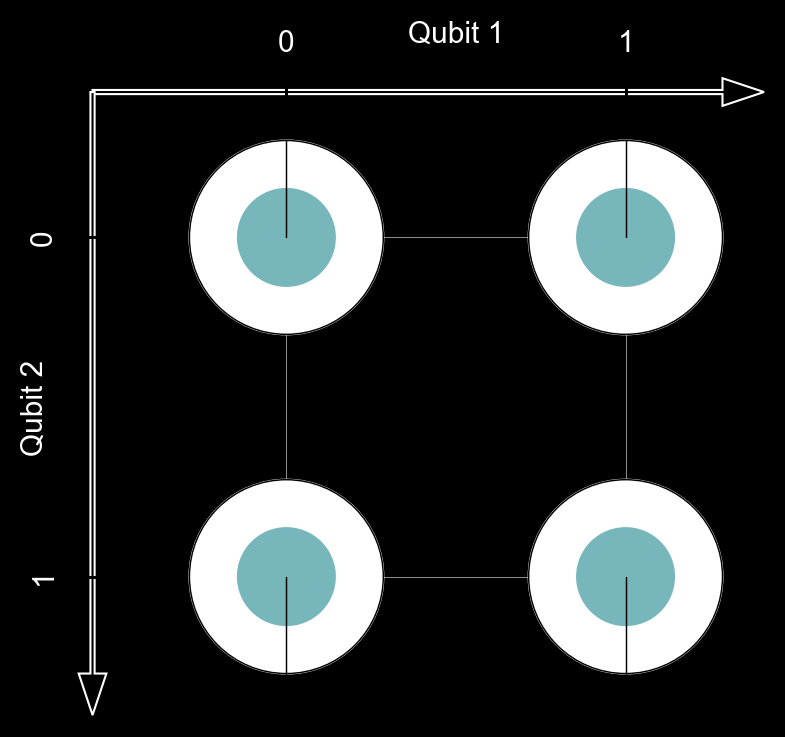


--- State AFTER CNOT ---
[ 0.5+0.j -0.5+0.j -0.5+0.j  0.5+0.j]

Visualization AFTER CNOT (Notice the phase shift!):


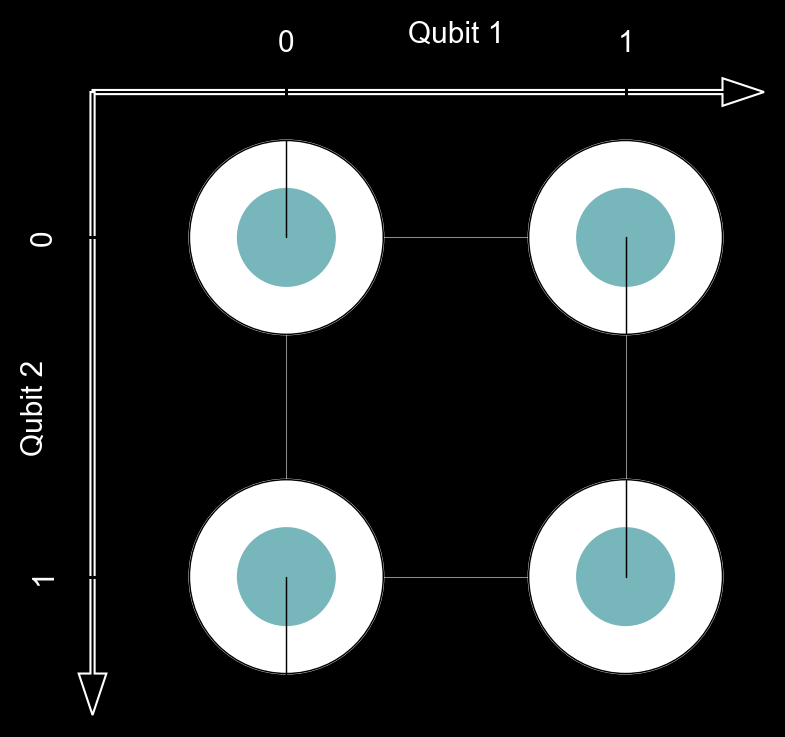


Circuit Diagram:


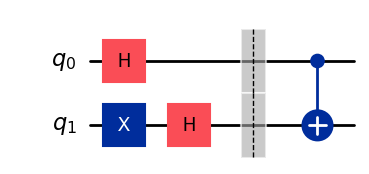


Interactive Challenge Viewer:


In [6]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# Import custom visualization and interactive tools
from qc_interactive_education_package import DimensionalCircleNotation
from qc_interactive_education_package import ChallengeViewer

# Create a 2-qubit circuit
# Qubit 0 will be our Control
# Qubit 1 will be our Target
qc = QuantumCircuit(2)

# 1. Prepare the Control in |+>
qc.h(0)

# 2. Prepare the Target in |->
# (Apply X to get |1>, then H to get |->)
qc.x(1)
qc.h(1)

print("--- State BEFORE CNOT ---")
sv_before = Statevector.from_instruction(qc)
print(np.round(sv_before.data, 3))

# Visualize state before Phase Kickback
print("\nVisualization BEFORE CNOT:")
DimensionalCircleNotation.from_qiskit(qc).show()

qc.barrier()

# 3. Apply the CNOT gate
qc.cx(0, 1)

print("\n--- State AFTER CNOT ---")
sv_after = Statevector.from_instruction(qc)
print(np.round(sv_after.data, 3))

# Visualize state after Phase Kickback
# Notice the phase change on the control qubit!
print("\nVisualization AFTER CNOT (Notice the phase shift on the control qubit, rather than the target qubit!):")

DimensionalCircleNotation.from_qiskit(qc).show()

# 4. Implement the ChallengeViewer for interactive exploration
print("\nInteractive Challenge Viewer:")
viewer = ChallengeViewer(
    num_qubits=2,
    preloaded_circuit=qc,
    is_assessment=False
)
viewer.display()

## 10.4. Analyzing the Results

Look closely at the statevectors printed above (keeping in mind Qiskit's little-endian ordering, where the state is written as $|q_1 q_0\rangle$).

1. **Before CNOT:** The state is $|-\rangle_1 \otimes |+\rangle_0$. If we expand this, we get $\frac{1}{2}(|00\rangle + |01\rangle - |10\rangle - |11\rangle)$.
2. **After CNOT:** The state becomes $|-\rangle_1 \otimes |-\rangle_0$. Expanding this gives $\frac{1}{2}(|00\rangle - |01\rangle - |10\rangle + |11\rangle)$.

The CNOT gate effectively applied a $Z$-gate to the control qubit, flipping its relative phase, while leaving the target qubit entirely untouched.

<div style="background-color: #6ab2e7; color: #042c58; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
<strong>Why does this matter?</strong><br>
Phase kickback is the mechanism that allows quantum algorithms to extract information from a "black box" (an Oracle) without directly measuring it. The Oracle applies a phase shift to a target register, and kickback transfers that phase into the amplitudes of the control register, where we can use interference to find our answer!
</div>

## 10.5. The CNOT Directional Inversion

A direct and mathematically rigorous consequence of phase kickback is the basis-transformation identity of the CNOT gate. When a CNOT gate is conjugated by Hadamard gates on both the control and target qubits, the direction of the control logic is entirely reversed.



This occurs because the initial Hadamard operations transform the system from the computational $Z$-basis into the transversal $X$-basis. In this superposition basis, the action of a Pauli-$X$ operation on the target is functionally equivalent to a Pauli-$Z$ phase operation. As dictated by the mechanics of phase kickback, this controlled phase operation acts back upon the original control qubit, altering its state while leaving the original target's probability amplitudes unchanged.

Algebraically, this structural inversion is expressed as the exact identity:

$$(H \otimes H) CNOT_{c,t} (H \otimes H) = CNOT_{t,c}$$

This equivalence is a fundamental topological tool. In hardware architectures where physical couplings only permit CNOT gates in one specific direction, this identity provides an alternative solution to reverse the gate's effective direction entirely through software, bypassing physical constraints.

---

<div style="background-color: #e31b4c; color: #ffffff; padding: 15px; border-radius: 5px; border: 1px solid #042c58;">
<strong>Your Task: Prove the Operator Identity</strong><br>
Testing a single initial state is useful for intuition, but proving that two circuits are universally equivalent requires comparing their underlying unitary matrices. Using Qiskit, rigorously prove that reversing a CNOT gate with Hadamards is mathematically equivalent to a native reversed CNOT gate.
<br><br>
1. Create a 2-qubit circuit (Circuit A) that applies $H$ to both qubits, a $CNOT$ from qubit 0 to qubit 1, and $H$ to both qubits again.<br>
2. Create a second 2-qubit circuit (Circuit B) that simply applies a $CNOT$ from qubit 1 to qubit 0.<br>
3. Extract the unitary matrices for both circuits using the <code>Operator</code> class from <code>qiskit.quantum_info</code>.<br>
4. Compare the matrices to confirm they are identical.
</div>


In [10]:
import numpy as np
from qc_interactive_education_package import ChallengeViewer
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, random_statevector

# Define an asymmetric initial state to rigorously test the identity
# Amplitudes correspond to |00>, |01>, |10>, |11>
initial_state = random_statevector(4)
initial_state = Statevector(np.exp(-1j * np.angle(initial_state.data[0])) * initial_state.data)

# Circuit 1: Hadamards first, then CNOT(0, 1)
qc_1 = QuantumCircuit(2)
qc_1.initialize(initial_state) # Alternatively, use qc_1.initialize(initial_state, [0, 1])
qc_1.h([0, 1])
qc_1.cx(0, 1)

# Viewer 1
viewer_1 = ChallengeViewer(
    num_qubits=2,
    preloaded_circuit=qc_1,
    is_assessment=False
)
viewer_1.display()

In [11]:
# Circuit 2: CNOT(1, 0) first, then Hadamards
qc_2 = QuantumCircuit(2)
qc_2.initialize(initial_state)
qc_2.cx(1, 0)
qc_2.h([0, 1])

# Viewer 2
viewer_2 = ChallengeViewer(
    num_qubits=2,
    preloaded_circuit=qc_2,
    is_assessment=False
)
viewer_2.display()

In [9]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
import numpy as np

# 1. Build Circuit A: Conjugated CNOT
qc_a = QuantumCircuit(2)
qc_a.h([0, 1])
qc_a.cx(0, 1)
qc_a.h([0, 1])

# 2. Build Circuit B: Native Reversed CNOT
qc_b = QuantumCircuit(2)
qc_b.cx(1, 0)

# 3. Extract the Unitary Operators
# The Operator class calculates the global matrix for the entire circuit
op_a = Operator(qc_a)
op_b = Operator(qc_b)

# 4. Compare the matrices
# We use np.allclose to account for potential minor floating-point inaccuracies
# inherent in matrix multiplication during simulation.
are_equivalent = np.allclose(op_a.data, op_b.data)

print("Circuit A (H-CNOT-H) Unitary Matrix:")
print(np.round(op_a.data, 3))

print("\nCircuit B (Reversed CNOT) Unitary Matrix:")
print(np.round(op_b.data, 3))

print(f"\nConclusion: Are the operators mathematically identical? {are_equivalent}")

Circuit A (H-CNOT-H) Unitary Matrix:
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]]

Circuit B (Reversed CNOT) Unitary Matrix:
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]]

Conclusion: Are the operators mathematically identical? True


### 10.6. Conclusion and Outlook: The Engine of Quantum Algorithms

We have rigorously examined the phenomenon of **Phase Kickback**, demonstrating that quantum control logic is fundamentally bidirectional. When a target register is prepared in an eigenstate of the controlled unitary operator, the operation leaves the target state invariant. Instead, the associated eigenvalue (the phase) is entirely transferred—or "kicked back"—to the probability amplitudes of the control register.

This effect is not a mathematical artifact; it is a direct consequence of the linearity of quantum mechanics and the tensor product structure of composite Hilbert spaces. As we demonstrated with the structural inversion of the CNOT gate, transforming the system into the transversal $X$-basis allows us to manipulate this kickback to reverse the effective direction of quantum operations, providing a critical topological workaround for physical hardware constraints.

#### Outlook: The Bridge to Universal Quantum Advantage

Phase kickback extends far beyond gate identities; it is the critical mechanism that elevates quantum computing from simple information transmission to exponential computational advantage. It serves as the underlying algebraic engine for several landmark quantum algorithms:

1. **Grover's Search Algorithm:** The quantum oracle in Grover's algorithm leverages phase kickback to apply a negative phase (a $-1$ eigenvalue) exclusively to the state representing the correct search solution. This "marks" the target mathematically without measuring or collapsing the system. Subsequent amplitude amplification then drives the system toward this marked state, yielding a proven quadratic speedup over any classical search algorithm.

2. **Quantum Phase Estimation (QPE):** By applying controlled unitary operations across a superposition of control qubits, QPE utilizes phase kickback to accurately read out the unknown eigenvalues of a quantum system into the control register. QPE is the foundational subroutine of **Shor's Algorithm** (enabling polynomial-time prime factorization) and is vital for calculating exact molecular energy spectra in quantum chemistry.

Mastering the mechanics of phase kickback marks the intellectual transition from reasoning about basic communication protocols to architecting complex, universally advantageous quantum algorithms.